# Ibis on &#x1F525;: Using Ibis with Torch

In this blog post we show how to leverage ecosystem tools to build an end-to-end ML pipeline using Ibis, DuckDB and PyTorch.

Check out the live stream of this notebook here: https://www.youtube.com/live/L4_deAdStKs?feature=share

Let's get started!

In [1]:
import ibis
import ibis.expr.datatypes as dt

from ibis import _, selectors as s, udf

In [2]:
ibis.options.interactive = True

## Define a Function to Clean Inputs

Let's define a function to clean the data in a few different ways:

- Remove outliers ($Z$-score based)
- Remove negative trip distances and negative fare amounts
- Cast inputs to `float32`, since that's what PyTorch wants

We use a function here ito ensure that we can run the same code on the test data set before inference.

In [3]:
def clean_input(path):
    return (
        # load parquet
        ibis.read_parquet(path)
        # compute fare_amount_zscore and trip_distance_zscore
        .mutate(s.across(["fare_amount", "trip_distance"], dict(zscore=(_ - _.mean()) / _.std())))
        # filter out negative trip distance and bizarre transactions
        .filter([_.trip_distance > 0.0, _.fare_amount >= 0.0])
        # keep values that within 2 standard deviations
        .filter(s.if_all(s.endswith("_zscore"), _.abs() <= 2))
        # drop columns that aren't necessary for further analysis
        .drop(s.endswith("_zscore"))
        # select the columns we care about
        .select(s.across(["fare_amount", "trip_distance"], _.cast("float32")))
    )

In [4]:
training_data = clean_input("/home/cloud/data/trip-data/yellow_tripdata_2016-01.parquet")

In [5]:
training_data

┏━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓
┃ trip_distance ┃ fare_amount ┃
┡━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩
│ float32       │ float32     │
├───────────────┼─────────────┤
│          3.20 │        14.0 │
│          1.00 │         9.5 │
│          0.90 │         6.0 │
│          0.80 │         5.0 │
│          1.80 │        11.0 │
│          2.30 │        11.0 │
│         13.80 │        43.0 │
│          3.46 │        20.0 │
│          0.83 │         5.5 │
│          0.87 │         7.0 │
│             … │           … │
└───────────────┴─────────────┘

## Execute the Query and Convert to Torch Tensors

In [6]:
torch_training_data = training_data.to_torch()  # type: dict[str, Tensor]

In [7]:
torch_training_data

{'trip_distance': tensor([3.2000, 1.0000, 0.9000,  ..., 5.6300, 0.7700, 1.2600]),
 'fare_amount': tensor([14.0000,  9.5000,  6.0000,  ..., 18.5000,  5.0000,  6.5000])}

## Train the Model

Let's assume for now we don't have access to the model code. Maybe your co-worker wrote the model or it's part of an API that you don't control. Either way, it's a black box to us.

The API looks like this:

```python
class PredictCabFare:
    def __init__(data: dict[str, tensor]):
        """Initialize the model with training data."""

    def train(self):
        """Train the model."""

    def __call__(self, input: pyarrow.ChunkedArray):
        """Invoke the trained model on unseen input."""
```

In [8]:
from model import PredictCabFare


model = PredictCabFare(torch_training_data)
model.train()

100%|███████████████████████████████████████████████████████████████████████████████| 100/100 [00:04<00:00, 22.17it/s]


## Define an Ibis UDF that Runs Inference

Now we get to the meaty part: defining an Ibis UDF (user-defined function) that accepts PyArrow arrays as input and returns them as output. This allows us to invoke arbitrary Python code, which includes running inference using the PyTorch model we just trained!

In [9]:
from ibis.expr.operations import udf


@udf.scalar.pyarrow
def predict_fare(distance: dt.float64) -> dt.float32:
    return model(distance)

In [10]:
## Visualize the comparison between the predicted cab fares and the actual cab fares
prediction = clean_input(
    "/home/cloud/data/trip-data/yellow_tripdata_2016-02.parquet"
).limit(10_000).mutate(
    predicted_fare=lambda t: predict_fare(t.trip_distance.cast("float32")),
)
prediction

┏━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┓
┃ trip_distance ┃ fare_amount ┃ predicted_fare ┃
┡━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━┩
│ float32       │ float32     │ float32        │
├───────────────┼─────────────┼────────────────┤
│           9.1 │        27.0 │      29.028614 │
│           3.3 │        11.5 │      12.736431 │
│           0.5 │         4.0 │       4.871240 │
│           7.4 │        26.5 │      24.253319 │
│           1.6 │         7.5 │       7.961137 │
│           3.8 │        16.0 │      14.140930 │
│           1.1 │         6.0 │       6.556638 │
│           6.8 │        21.0 │      22.567921 │
│           2.9 │        12.0 │      11.612833 │
│           1.2 │         6.5 │       6.837538 │
│             … │           … │              … │
└───────────────┴─────────────┴────────────────┘

In [11]:
pivoted_prediction = prediction.pivot_longer(~s.c("trip_distance"), values_to="fare", names_to="metric")

In [12]:
pivoted_prediction

┏━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ trip_distance ┃ metric         ┃ fare      ┃
┡━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ float32       │ string         │ float32   │
├───────────────┼────────────────┼───────────┤
│           9.1 │ fare_amount    │ 27.000000 │
│           9.1 │ predicted_fare │ 29.028614 │
│           3.3 │ fare_amount    │ 11.500000 │
│           3.3 │ predicted_fare │ 12.736431 │
│           0.5 │ fare_amount    │  4.000000 │
│           0.5 │ predicted_fare │  4.871240 │
│           7.4 │ fare_amount    │ 26.500000 │
│           7.4 │ predicted_fare │ 24.253319 │
│           1.6 │ fare_amount    │  7.500000 │
│           1.6 │ predicted_fare │  7.961137 │
│             … │ …              │         … │
└───────────────┴────────────────┴───────────┘

## Plot the Results

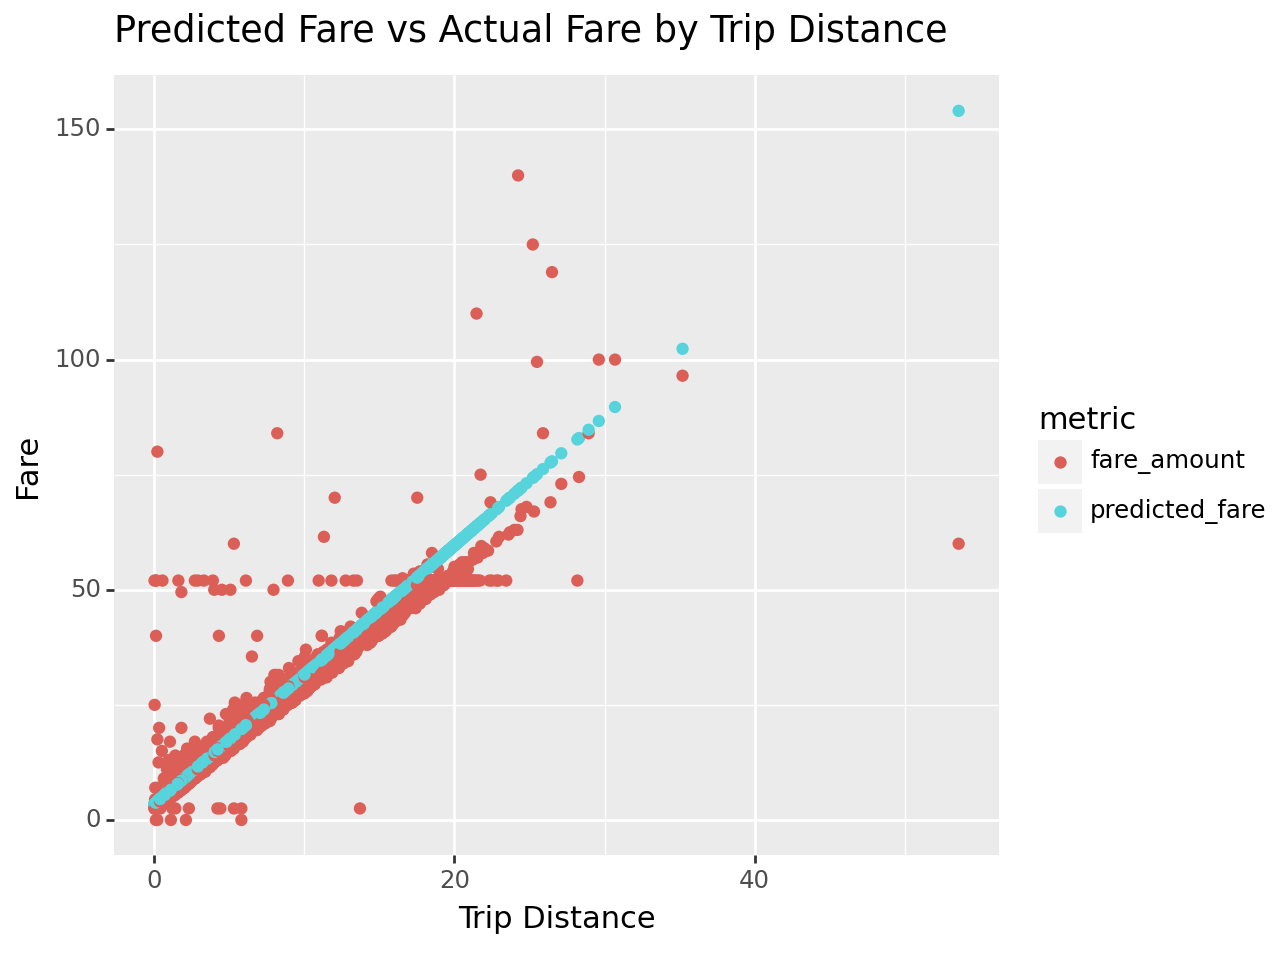

<Figure Size: (640 x 480)>

In [13]:
from plotnine import aes, ggtitle, ggplot, geom_point, xlab, ylab

(
    ggplot(pivoted_prediction, aes(x="trip_distance", y="fare", color="metric"))
    + geom_point()
    + xlab("Trip Distance")
    + ylab("Fare")
    + ggtitle("Predicted Fare vs Actual Fare by Trip Distance")
)

# Appendix: `model.py`

In [14]:
%pycat model.py

import pyarrow as pa
import torch
import tqdm
from torch import nn


class LinearRegression(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, output_dim)

    def forward(self, distances):
        return self.linear(distances)


class PredictCabFare:
    def __init__(self, data, learning_rate: float = 0.01, epochs: int = 100) -> None:
        # Define the input and output dimensions
        input_dim = 1
        output_dim = 1

        # Create a linear regression model instance
        self.data = data
        self.model = LinearRegression(input_dim, output_dim)
        self.learning_rate = learning_rate
        self.epochs = epochs

    def train(self):
        distances = self.data["trip_distance"].reshape(-1, 1)
        fares = self.data["fare_amount"].reshape(-1, 1)

        # Define the loss function
        criterion = nn.MSELoss()

        # Define the optimizer
        optimizer = torch.optim.SGD(se